In [ ]:
import marimo as mo
from cpuinfo import get_cpu_info
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import numpy as np
from transformers import (
    MarianTokenizer,
    MarianMTModel,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from tqdm.notebook import tqdm
from datasets import load_dataset
import evaluate
import datasets as hf_datasets

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

In [ ]:
if device == "cuda":
    print(torch.cuda.get_device_name(0))
else:
    print(get_cpu_info()['brand_raw'])

NVIDIA GeForce RTX 4050 Laptop GPU


## Модель: [Helsinki-NLP/opus-mt-ru-en](https://huggingface.co/Helsinki-NLP/opus-mt-ru-en)

In [ ]:
model_name = "Helsinki-NLP/opus-mt-ru-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name, torch_dtype=dtype, use_safetensors=True).to(device)

model.generation_config.max_length = None
model.generation_config.max_new_tokens = 256

TARGET_LANG_CODE = ">>eng<<"
FORCED_BOS_ID = tokenizer.convert_tokens_to_ids(TARGET_LANG_CODE)

C:\Users\Michael\Desktop\ML\env\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 256/256 [00:00<00:00, 1601.36it/s]


In [ ]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

## Метрика [BLEU](https://github.com/huggingface/evaluate/blob/main/metrics/bleu/README.md)

In [ ]:
bleu = evaluate.load("bleu")

In [ ]:
def get_bleu(predictions, references, metric):
    return metric.compute(predictions=predictions, references=references, smooth=True)

## Методы тестирования

### Пайплайн перевода (пакетный)

In [ ]:
def translate_batch(texts, tokenizer, model, device, forced_bos_token_id, batch_size=128):
    predictions = []
    model.eval()
    with torch.inference_mode(), tqdm(total=len(texts), desc="Перевод", unit="пример") as pbar:
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]

            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding="longest",
                truncation=True,
                max_length=512,
            ).to(device)

            translated = model.generate(
                **inputs,
                max_new_tokens=256,
                max_length=None,
                num_beams=1,
                do_sample=False,
                forced_bos_token_id=forced_bos_token_id,
                pad_token_id=tokenizer.pad_token_id,
            )

            batch_res = tokenizer.batch_decode(translated, skip_special_tokens=True)
            predictions.extend(batch_res)

            pbar.update(len(batch))
            torch.cuda.empty_cache()

    return predictions

### Получение метрики BLEU модели на датасетах

In [ ]:
def evaluate_on_tests(model, tokenizer, device, forced_bos_id, stage_label="Model"):
    all_records = []
    for ds_name, test_data in test_sets.items():
        ru_texts = [x["ru"] for x in test_data]
        en_refs = [x["en"] for x in test_data]
        preds = translate_batch(ru_texts, tokenizer, model, device, forced_bos_id)

        for ru, en, pred in zip(ru_texts, en_refs, preds):
            sent_bleu = get_bleu([pred], [en], bleu)["bleu"]
            all_records.append({
                "Dataset": ds_name,
                "Stage": stage_label,
                "Source_RU": ru,
                "Reference_EN": en,
                "Prediction_EN": pred,
                "BLEU_Sentence": sent_bleu,
            })
    return pd.DataFrame(all_records)

### Визуализация результатов

In [ ]:
def plot_avg_bleu_comparison(df_results, title="Средний BLEU по доменам"):
    avg = df_results.groupby(["Dataset", "Stage"])["BLEU_Sentence"].mean().reset_index()
    avg.columns = ["Dataset", "Stage", "Avg_BLEU"]

    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        data=avg,
        x="Dataset",
        y="Avg_BLEU",
        hue="Stage",
        palette="viridis",
    )

    for container in ax.containers:
        if len(container) > 0:
            ax.bar_label(
                container,
                fmt="%.3f",
                padding=3,
                fontsize=9,
                labels=[f"{h:.4f}" if h < 0.01 else f"{h:.2f}" 
                       for h in [p.get_height() for p in container]]
            )

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Датасет", fontsize=12)
    plt.ylabel("Avg BLEU Score", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Этап модели")
    plt.tight_layout()
    plt.show()
    return avg

## Данные

### Загрузка и разделение датасетов на обучающую и тестовую выборки

In [ ]:
def load_and_split_dataset(path: str, cfg: str, split: str = "train",
                           seed: int = SEED,
                           train_size: int = 2000, test_size: int = 500, min_words: int = 5,
                           source_lang: str = "ru", target_lang: str = "en"):
    ds = load_dataset(path, cfg, split=split, streaming=True)
    ds = ds.shuffle(seed=seed, buffer_size=10_000)

    target_total = train_size + test_size
    collected = []
    iterations = 0

    with tqdm(total=target_total, desc=f"Сбор данных ({path})", leave=False) as pbar:
        for item in ds:
            iterations += 1
            tr = item.get("translation", item)
            ru = tr.get(source_lang) or tr.get(f"{source_lang}-{source_lang.upper()}")
            en = tr.get(target_lang) or tr.get(f"{target_lang}-{target_lang.upper()}")
            if ru and en and len(ru.split()) > min_words:
                collected.append({"ru": ru, "en": en})
                pbar.update(1)
            if len(collected) >= target_total:
                break
            if iterations >= 20000: 
                break

    train_data = collected[:train_size]
    test_data = collected[train_size:]
    return train_data, test_data

### Датасеты
* [Общий датасет](https://huggingface.co/datasets/Helsinki-NLP/opus-100)
* [Научный датасет (Википедия)](https://huggingface.co/datasets/Helsinki-NLP/opus_wikipedia/viewer/en-ru)
* [Официально-деловой датасет (документы ООН)](https://huggingface.co/datasets/Helsinki-NLP/un_pc)
* [Художественный датасет](https://huggingface.co/datasets/Helsinki-NLP/opus_books)
* [Новостной датасет](https://huggingface.co/datasets/wmt/wmt19)

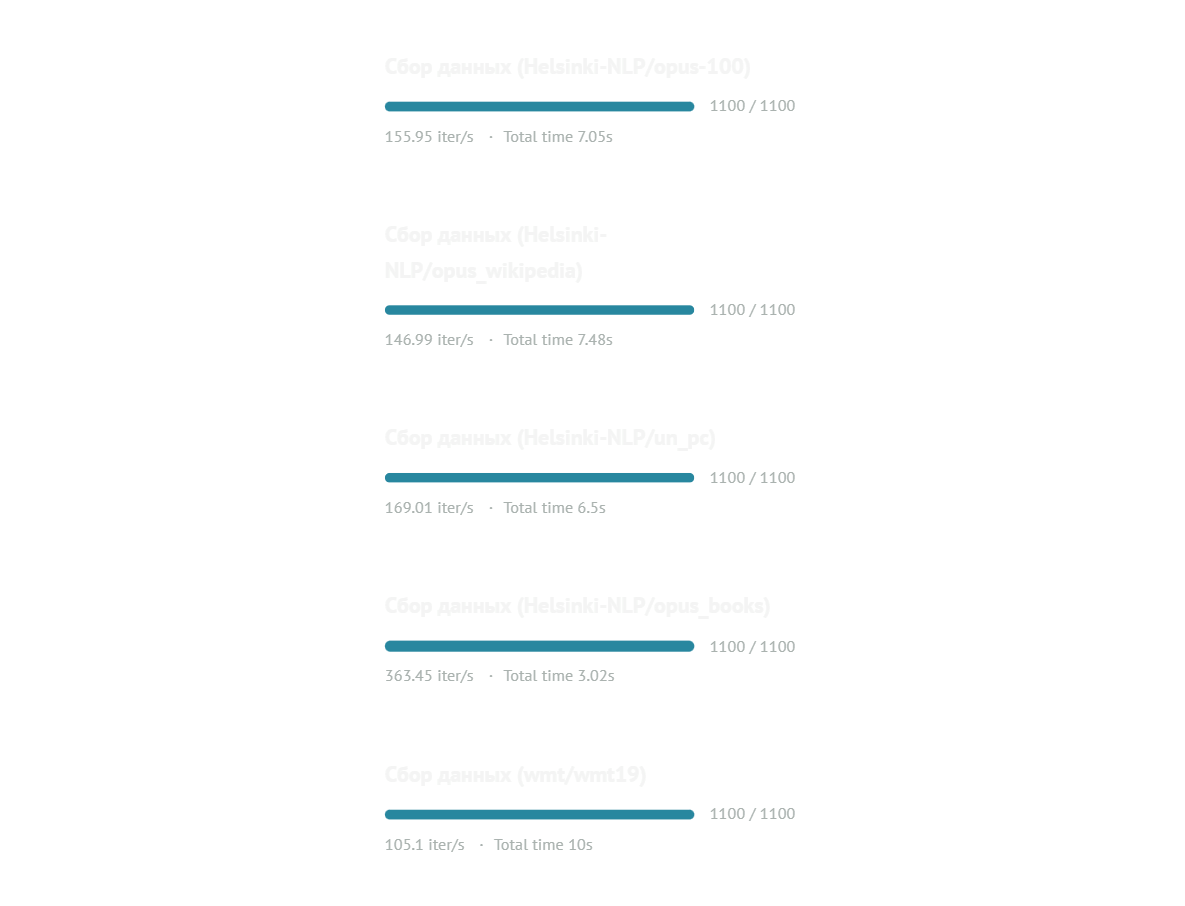

In [ ]:
TRAIN_SIZE = 1000
TEST_SIZE = 100

datasets_cfg = [
    {
        "name": "General (opus-100)",
        "path": "Helsinki-NLP/opus-100",
        "cfg": "en-ru",
        "split": "train",
        "seed": SEED,
        "train_size": TRAIN_SIZE,
        "test_size": TEST_SIZE,
    },
    {
        "name": "Wiki (Technical)",
        "path": "Helsinki-NLP/opus_wikipedia",
        "cfg": "en-ru",
        "split": "train",
        "seed": SEED,
        "train_size": TRAIN_SIZE,
        "test_size": TEST_SIZE,
    },
    {
        "name": "UN (Legal)",
        "path": "Helsinki-NLP/un_pc",
        "cfg": "en-ru",
        "split": "train",
        "seed": SEED,
        "train_size": TRAIN_SIZE,
        "test_size": TEST_SIZE,
    },
    {
        "name": "Books (Literary)",
        "path": "Helsinki-NLP/opus_books",
        "cfg": "en-ru",
        "split": "train",
        "seed": SEED,
        "train_size": TRAIN_SIZE,
        "test_size": TEST_SIZE,
    },
    {
        "name": "News (WMT19)",
        "path": "wmt/wmt19",
        "cfg": "ru-en",
        "split": "train",
        "seed": SEED,
        "train_size": TRAIN_SIZE,
        "test_size": TEST_SIZE,
    },
]

train_sets = {}
test_sets = {}

for cfg in datasets_cfg:
    train_d, test_d = load_and_split_dataset(
        path=cfg["path"],
        cfg=cfg["cfg"],
        split=cfg["split"],
        seed=cfg["seed"],
        train_size=cfg["train_size"],
        test_size=cfg["test_size"],
    )
    train_sets[cfg["name"]] = train_d
    test_sets[cfg["name"]] = test_d

## Тестирование

### Тестирование базовой предобученной модели на всех датасетах

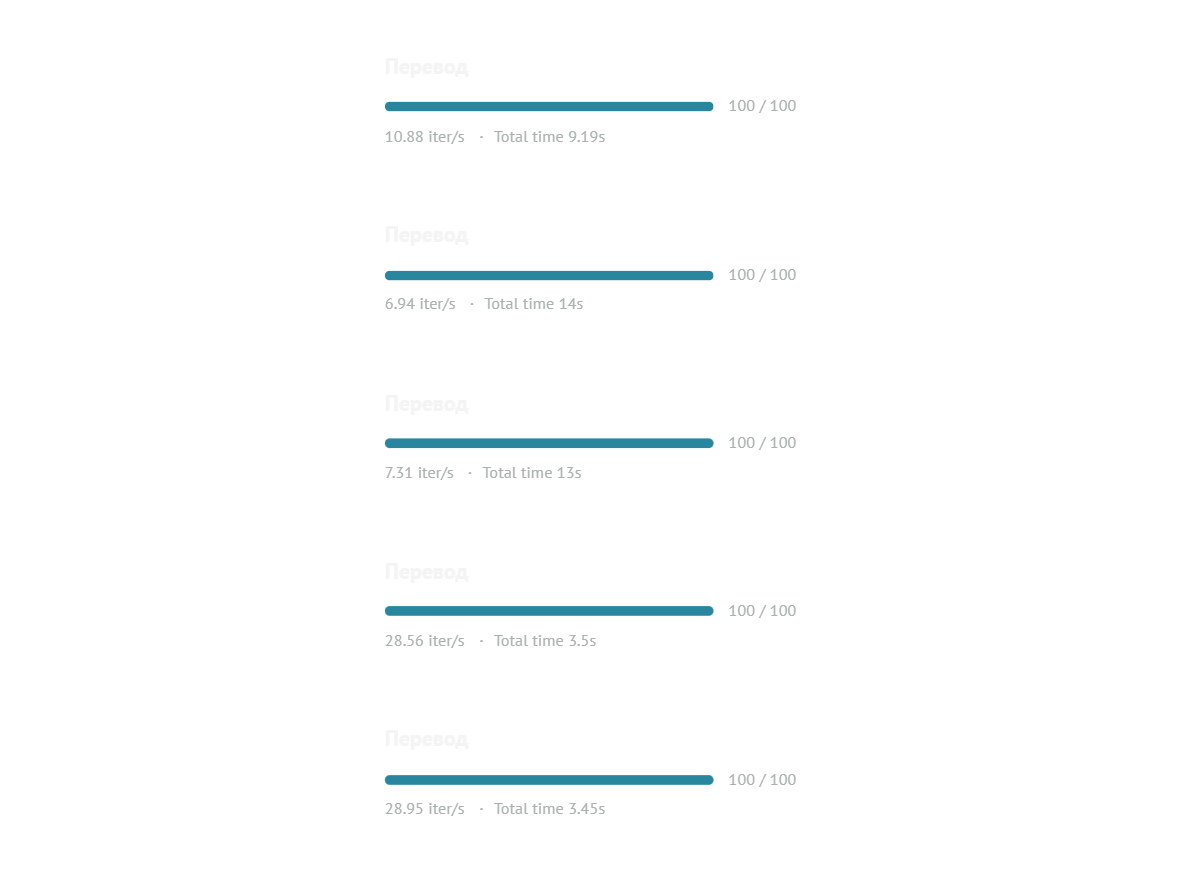

In [ ]:
df_base = evaluate_on_tests(model, tokenizer, device, FORCED_BOS_ID, stage_label="0. Original (Base)")

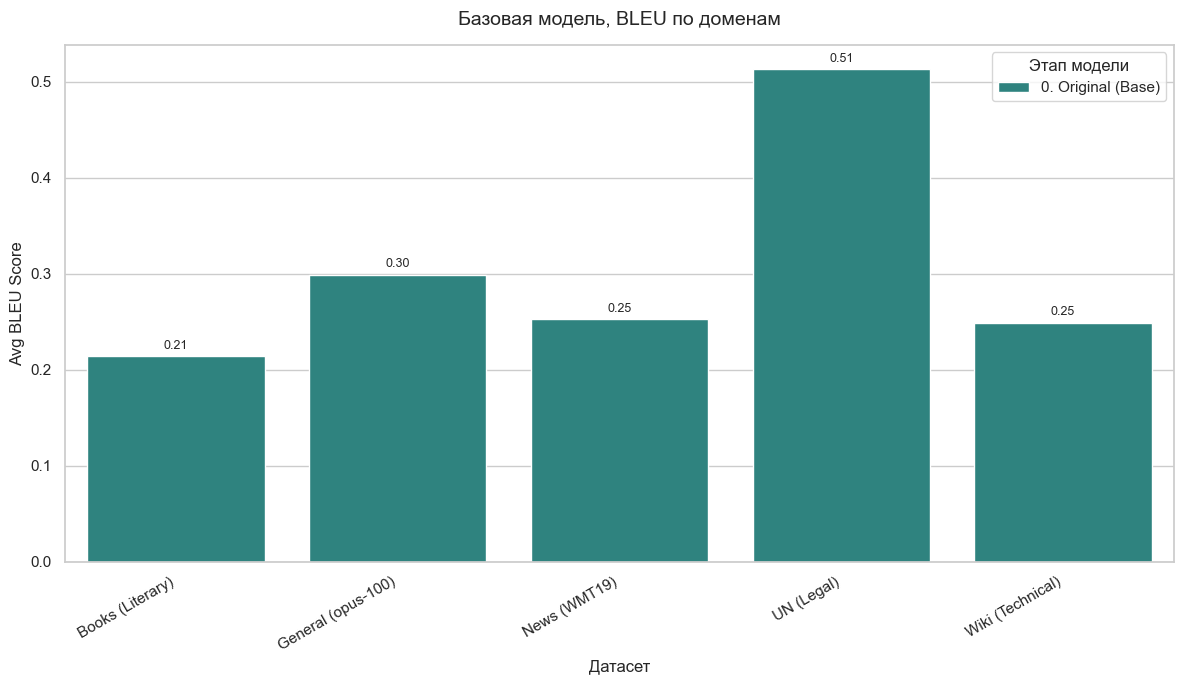

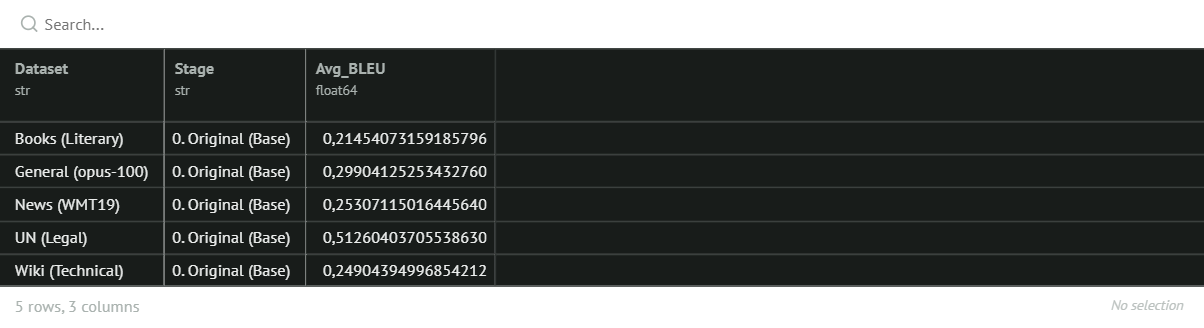

In [ ]:
avg_base = df_base.groupby("Dataset")["BLEU_Sentence"].mean().reset_index()
avg_base.columns = ["Dataset", "Avg_BLEU"]
mo.ui.table(avg_base, format_mapping={"Avg_BLEU": lambda x: f"{x:.4f}"})
plot_avg_bleu_comparison(df_base, title="Базовая модель, BLEU по доменам")

## Дообучение и повторное тестирование

In [ ]:
def finetune_model(train_data, dataset_name, num_epochs=3, learning_rate=3e-5):
    model_name = "Helsinki-NLP/opus-mt-ru-en"

    fresh_model = MarianMTModel.from_pretrained(
        model_name, use_safetensors=True
    )

    fresh_model.config.use_cache = False

    df_all = pd.DataFrame(train_data)
    hf_dataset = hf_datasets.Dataset.from_pandas(df_all)

    split_ds = hf_dataset.train_test_split(test_size=0.1, seed=SEED)

    def tokenize_fn(batch):
        return tokenizer(
            batch["ru"],
            text_target=batch["en"],
            truncation=True,
            max_length=256
        )

    tokenized_ds = split_ds.map(
        tokenize_fn, 
        batched=True, 
        remove_columns=hf_dataset.column_names
    )

    data_collator = DataCollatorForSeq2Seq(tokenizer, model=fresh_model, padding=True)

    use_bf16 = device == "cuda" and torch.cuda.is_bf16_supported()
    use_fp16 = device == "cuda" and not use_bf16

    total_steps = (len(tokenized_ds["train"]) // (8 * 2)) * num_epochs
    warmup_steps = int(total_steps * 0.1)

    training_args = Seq2SeqTrainingArguments(
        output_dir=f"./finetune_{dataset_name.replace(' ', '_')}",
        learning_rate=learning_rate,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        weight_decay=0.01,
        num_train_epochs=num_epochs,

        bf16=use_bf16,
        fp16=use_fp16,

        gradient_checkpointing=True,

        eval_strategy="steps",
        eval_steps=50, 
        save_strategy="steps",
        save_steps=50,
        logging_steps=25,

        load_best_model_at_end=True,
        metric_for_best_model="loss",
        greater_is_better=False,

        save_total_limit=1,
        report_to="none",
        predict_with_generate=False,
        warmup_steps=warmup_steps,
        seed=SEED
    )

    trainer = Seq2SeqTrainer(
        model=fresh_model,
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["test"],
        data_collator=data_collator,
    )

    train_result = trainer.train()

    fresh_model.config.use_cache = True

    return fresh_model.to(device)

### Дообучение на литературном датасете

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.36it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


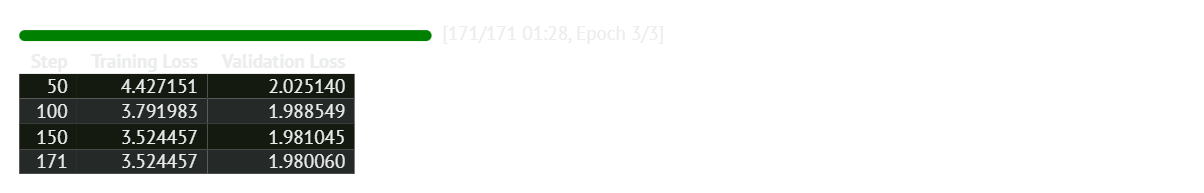

In [ ]:
model_1 = finetune_model(
    train_sets["Books (Literary)"],
    dataset_name="Books_Literary",
    num_epochs=3,
    learning_rate=3e-5,
)

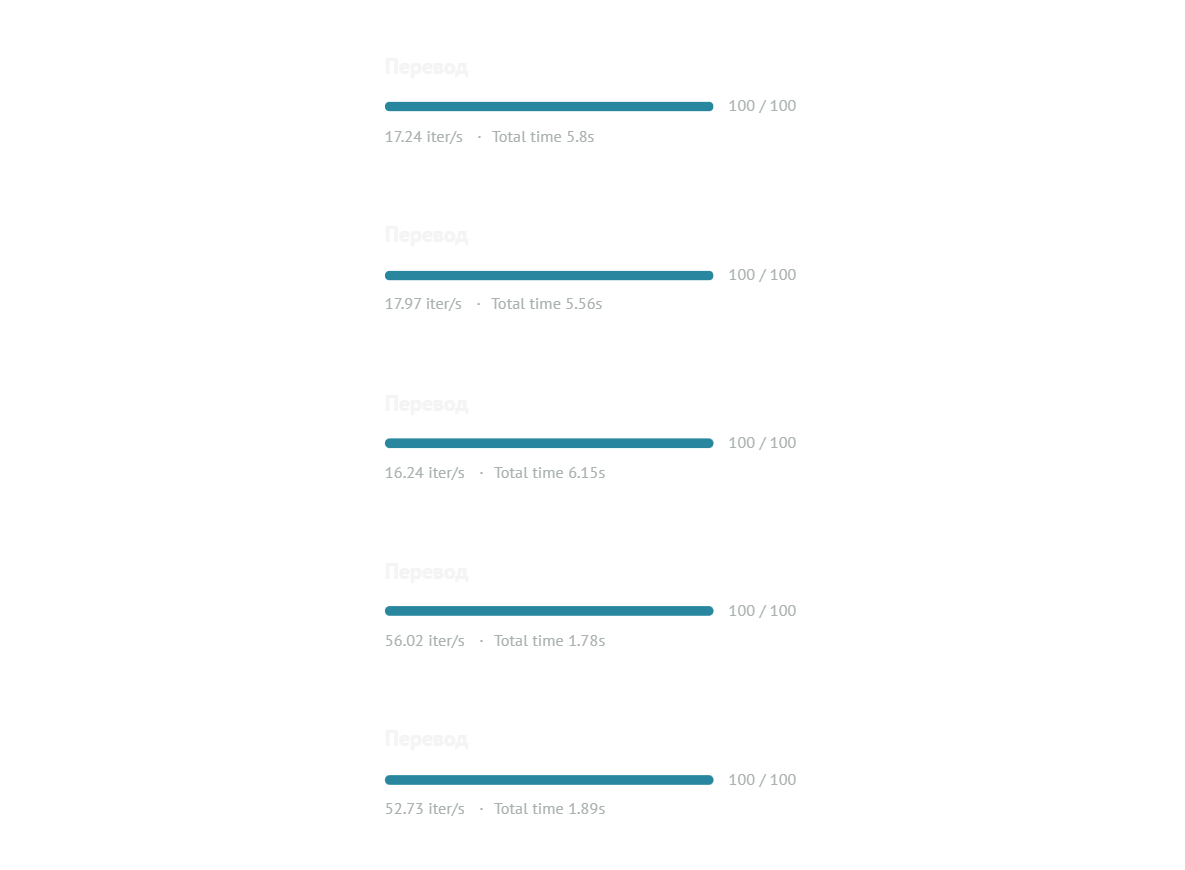

In [ ]:
df_after_books = evaluate_on_tests(
    model_1, tokenizer, device, FORCED_BOS_ID, stage_label="1. After Books FT"
)

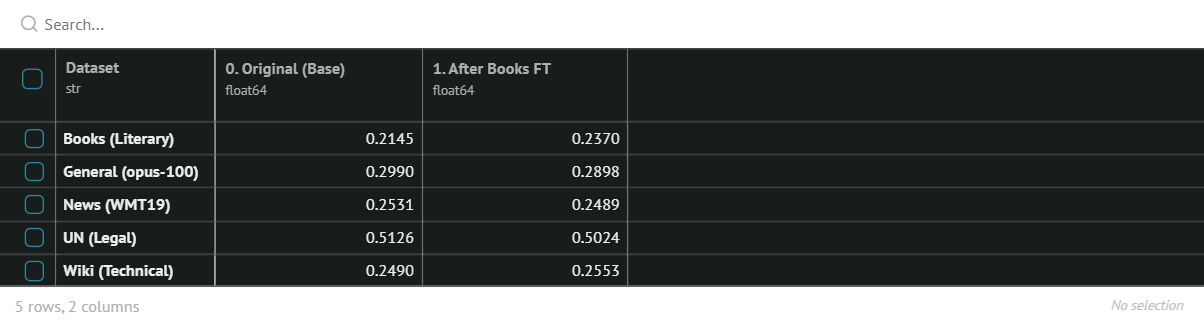

In [ ]:
df_combined = pd.concat([df_base, df_after_books], ignore_index=True)
pivot_df_after_books = df_combined.groupby(["Dataset", "Stage"])["BLEU_Sentence"].mean().unstack()

mo.ui.table(
    pivot_df_after_books, 
    format_mapping={col: lambda x: f"{x:.4f}" for col in pivot_df_after_books.columns}
)

### Дообучение на новостном датасете

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


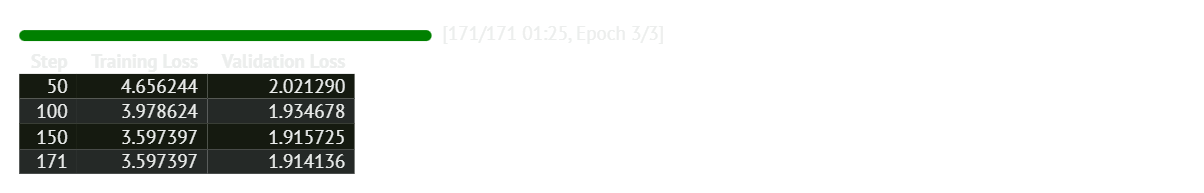

In [ ]:
model_2 = finetune_model(
    train_sets["News (WMT19)"],
    dataset_name="News_WMT19",
    num_epochs=3,
    learning_rate=3e-5,
)

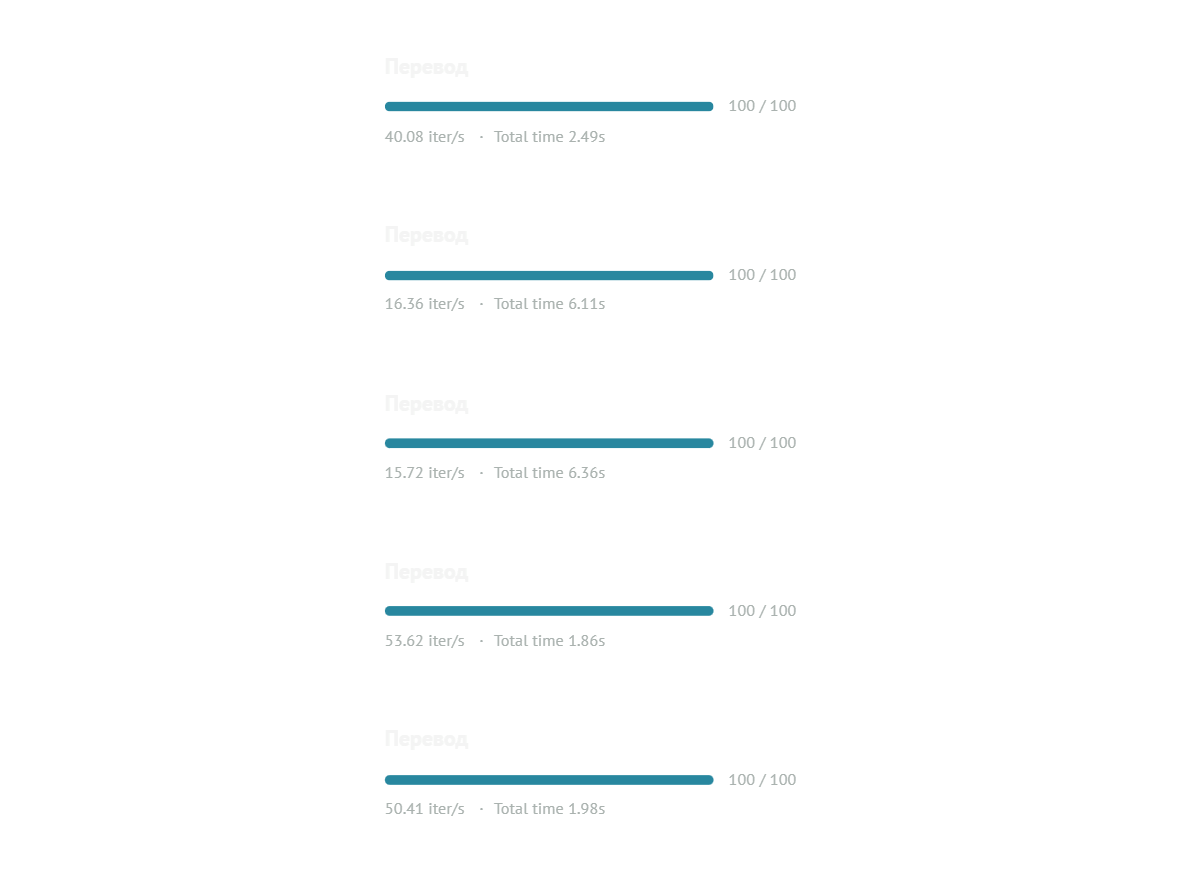

In [ ]:
df_after_news = evaluate_on_tests(
    model_2, tokenizer, device, FORCED_BOS_ID, stage_label="2. After News FT"
)

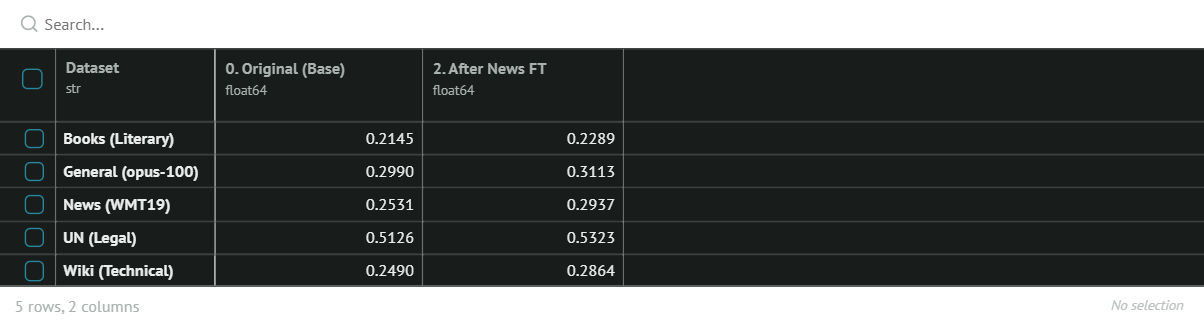

In [ ]:
df_combined_2 = pd.concat([df_base, df_after_news], ignore_index=True)
pivot_df_after_news = df_combined_2.groupby(["Dataset", "Stage"])["BLEU_Sentence"].mean().unstack()
mo.ui.table(
    pivot_df_after_news, 
    format_mapping={col: lambda x: f"{x:.4f}" for col in pivot_df_after_news.columns}
)

### Результаты тестирования дообученных моделей

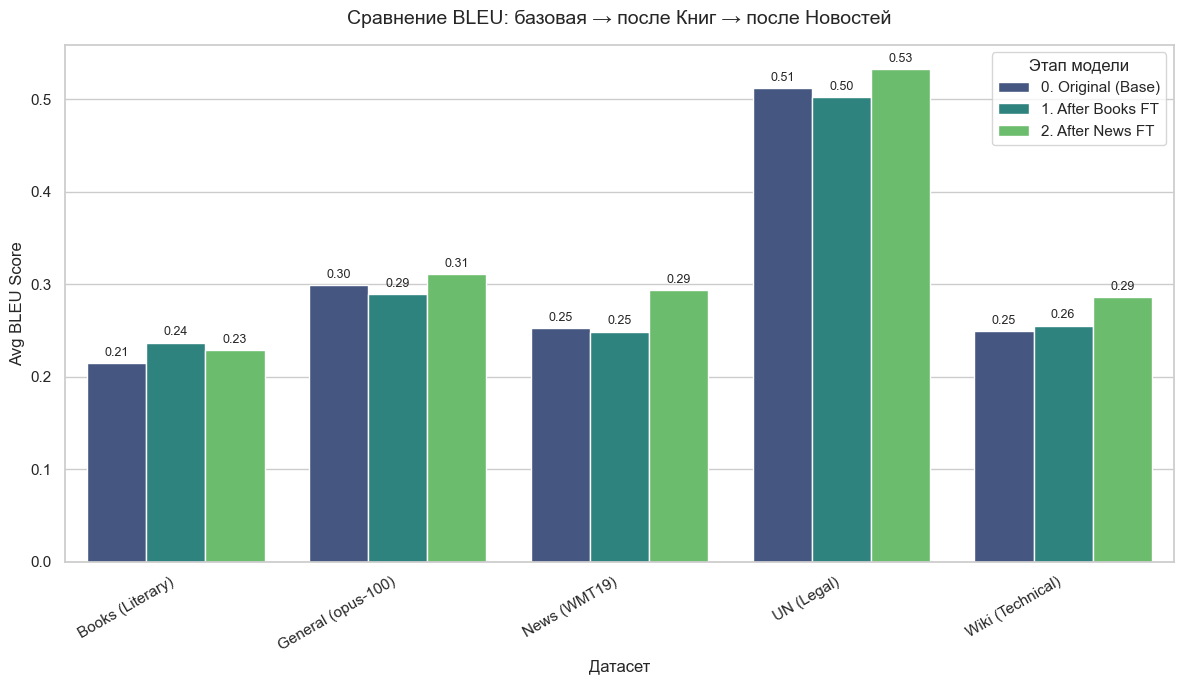

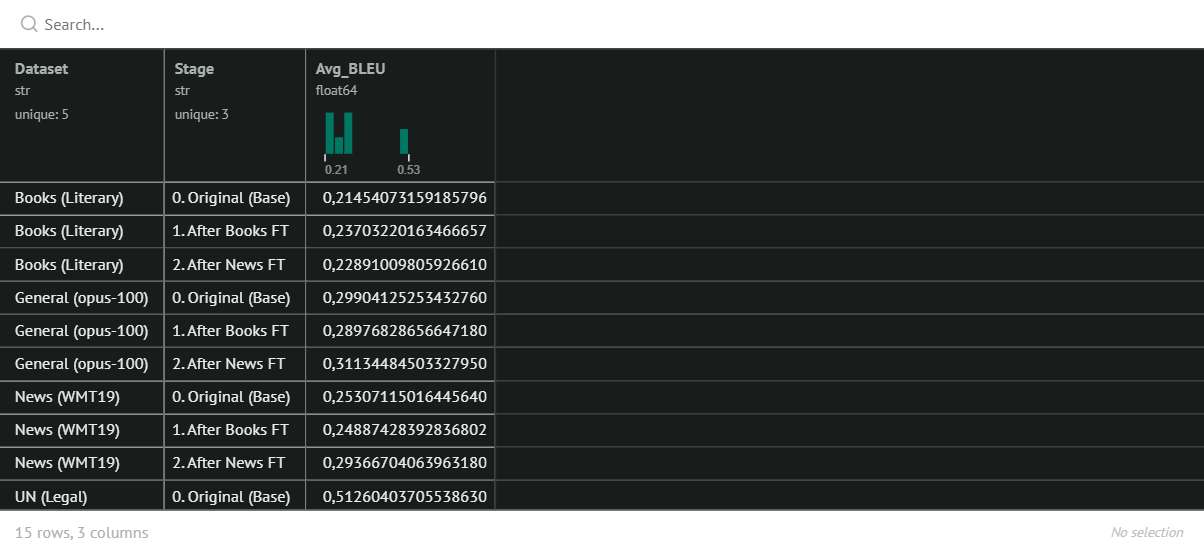

In [ ]:
df_final = pd.concat([df_combined, df_after_news], ignore_index=True)
pivot = df_final.groupby(["Dataset", "Stage"])["BLEU_Sentence"].mean().unstack()
mo.ui.table(
    pivot, 
    format_mapping={col: lambda x: f"{x:.4f}" for col in pivot.columns}
)
plot_avg_bleu_comparison(df_final, title="Сравнение BLEU: базовая → после Книг → после Новостей")

## Выводы

* Успешно удалось применить предобученную модель архитектуры трансформера: [Helsinki-NLP/opus-mt-ru-en](https://huggingface.co/Helsinki-NLP/opus-mt-ru-en) для перевода текста с русского языка на английский.
* Лучше всего модель справилась с переводом официально делового стиля и датасета с общим стилем (разговорный преимущественно)
* Если посмотреть на средние оценки по доменам, то результаты получились удовлетворительные. Но возможно модель слишком просто переводит текст.
* Кажется в датасете некоторые эталоны даны исходя из контекста, которого у модели нет.
* Модели, специализированные для конкретных языков требуют меньше ресурсов и работают также качествено по сравнению с мультиязычными моделями (пробовалась: [facebook/nllb-200-distilled-600M](https://huggingface.co/facebook/nllb-200-distilled-600M)).